Entrenamiento Supervisado

Predicción de categorías - Regresión logística

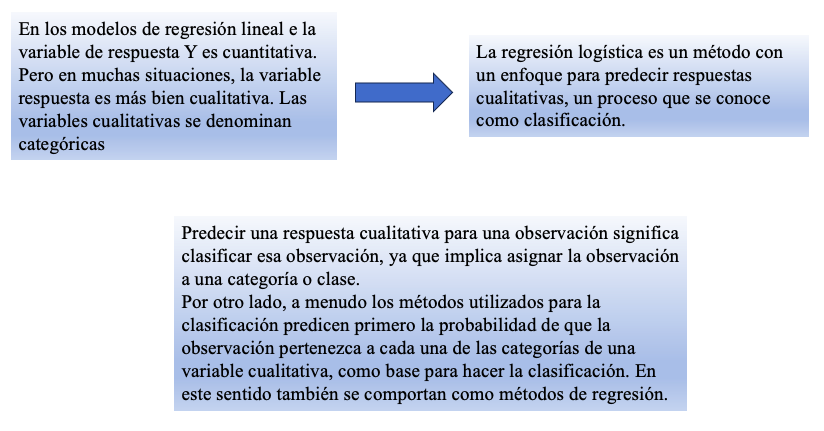

Ejemplo 1 - Regresión logística

---



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import seaborn as sns  # Para visualizar la matriz de confusión

In [ ]:
# Cargar los datos
# Cargar el dataset
url = 'https://raw.githubusercontent.com/selva86/datasets/master/Carseats.csv'
data = pd.read_csv(url)
data

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [ ]:
# Crear una nueva variable binaria para ventas altas/bajas
data['Ventas Altas'] = (data['Sales'] > data['Sales'].median()).astype(int)
data

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Ventas Altas
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes,1
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes,0
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes,0
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes,0


In [ ]:
# Seleccionar las variables predictoras y la variable objetivo
X = data[['Price', 'Advertising', 'Income', 'Population']]
y = data['Ventas Altas']

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Ajustar el modelo de regresión logística
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Predecir las etiquetas para el conjunto de prueba
y_pred = model.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1])

In [ ]:
# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.775

In [ ]:
# Calcular e imprimir la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print('Matriz de confusión:\n', conf_matrix)

Matriz de confusión:
 [[30  7]
 [11 32]]


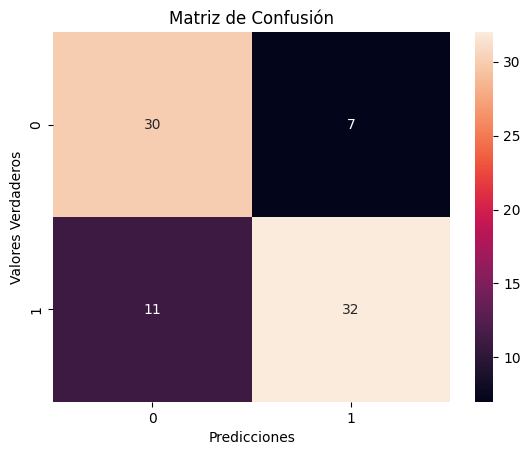

In [ ]:
# Visualizar la matriz de confusión usando Seaborn
sns.heatmap(conf_matrix, annot=True, fmt='g')
plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.show()

In [ ]:
# Imprimir el informe de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.81      0.77        37
           1       0.82      0.74      0.78        43

    accuracy                           0.78        80
   macro avg       0.78      0.78      0.77        80
weighted avg       0.78      0.78      0.78        80



Precision (Precisión): Esta métrica muestra, de todas las veces que el modelo predijo una clase específica, ¿cuántas de esas predicciones fueron correctas?

Para la clase 0 (Ventas Bajas): La precisión es 0.73. Esto significa que cuando el modelo predijo 'Ventas Bajas', el 73% de las veces su predicción fue correcta.

Para la clase 1 (Ventas Altas): La precisión es 0.82. Esto indica que cuando el modelo predijo 'Ventas Altas', el 82% de las veces su predicción fue correcta.

Recall (Sensibilidad): Esta métrica muestra, de todas las instancias que realmente pertenecen a una clase específica, ¿cuántas de ellas fueron identificadas correctamente por el modelo?

Para la clase 0 (Ventas Bajas): El recall es 0.81. Esto significa que el modelo identificó correctamente el 81% de las veces que realmente hubo 'Ventas Bajas'.

Para la clase 1 (Ventas Altas): El recall es 0.74. Esto indica que el modelo identificó correctamente el 74% de las veces que realmente hubo 'Ventas Altas'.

F1-Score: Es la media armónica de la precisión y el recall. Proporciona un balance entre ambas métricas. Un F1-score alto indica que el modelo tiene tanto una buena precisión como un buen recall. Aquí, el F1-score es 0.77 para la clase 0 y 0.78 para la clase 1, lo que sugiere un rendimiento bastante equilibrado.

Support (Soporte): Es el número real de instancias de cada clase en el conjunto de prueba. Para el conjunto de prueba, había 37 casos de 'Ventas Bajas' (clase 0) y 43 casos de 'Ventas Altas' (clase 1).

Accuracy (Exactitud): Es la proporción de predicciones correctas sobre el total de predicciones. En este caso, el modelo tuvo una exactitud general del 0.78, lo que significa que el 78% de todas las predicciones fueron correctas.

Macro Avg: Es el promedio simple (no ponderado) de la precisión, recall y f1-score de cada clase. Da el mismo peso a cada clase, independientemente de cuántos ejemplos haya en cada una.

Weighted Avg: Es el promedio de la precisión, recall y f1-score de cada clase, ponderado por el número de ejemplos (soporte) de cada clase. Es útil cuando las clases están desequilibradas, ya que da más importancia a las clases con más muestras.



---



In [ ]:
#ver probabilidades predichas
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Obtener los coeficientes del modelo
coefficients = model.coef_[0]
intercept = model.intercept_[0]

print('Coefficients:')
for feature, coef in zip(X.columns, coefficients):
    print(f'{feature}: {coef}')
print(f'Intercept: {intercept}')

# Mostrar las probabilidades predichas
print('Predicted Probabilities:')
print(y_pred_prob)


Coefficients:
Price: -0.042755165507800404
Advertising: 0.09975422438836605
Income: 0.003172719722761881
Population: 0.0003070100514035633
Intercept: 3.947234726002689
Predicted Probabilities:
[0.79629205 0.30373153 0.49731602 0.29474308 0.40527067 0.24400283
 0.79315931 0.76914063 0.68050081 0.21323608 0.27774594 0.65333715
 0.65306572 0.32366845 0.34922971 0.95881814 0.12885001 0.90001481
 0.26654648 0.49291445 0.82889942 0.21644147 0.24241567 0.39569673
 0.55731068 0.31007033 0.64433305 0.65636056 0.51763481 0.18190584
 0.64000184 0.68673661 0.37568928 0.31872271 0.6718734  0.22697764
 0.45251415 0.65748484 0.40178817 0.19484704 0.48614035 0.13436786
 0.91166752 0.64494033 0.22555155 0.70155932 0.57332476 0.58518714
 0.25808922 0.33751527 0.93347828 0.63016709 0.43916733 0.82354298
 0.44451779 0.15207666 0.43244911 0.71143241 0.64049061 0.23626553
 0.31663077 0.57286402 0.83200139 0.12373297 0.31529314 0.54992875
 0.63248043 0.41557874 0.54883888 0.69005214 0.25352293 0.42672288
 0.

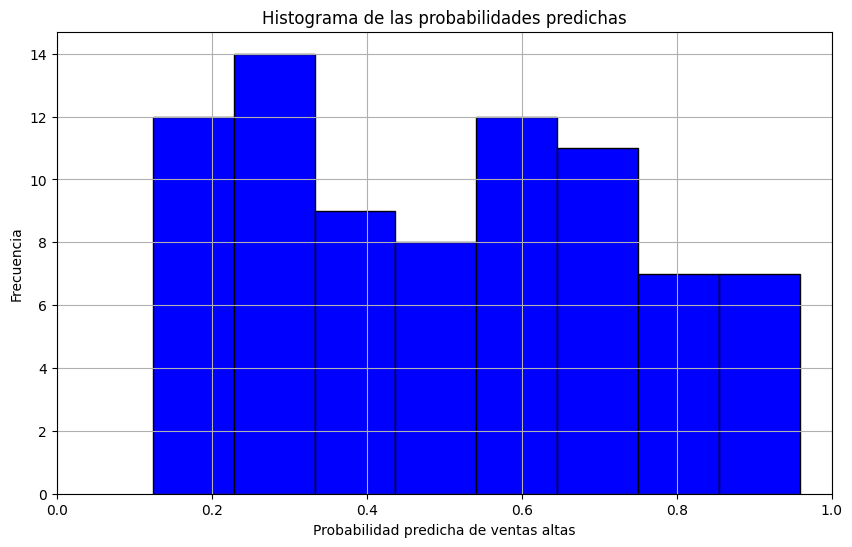

In [ ]:
# Crear un gráfico de las probabilidades predichas
# Obtener las probabilidades predichas
logit = LogisticRegression()
logit.fit(X_train, y_train)
prob = logit.predict_proba(X_test)
#armamos el gráfico

plt.figure(figsize=(10,6))
plt.hist(prob[:,1], bins=8, color='blue', edgecolor='black')
plt.xlim(0,1)
plt.title('Histograma de las probabilidades predichas')
plt.xlabel('Probabilidad predicha de ventas altas')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

In [ ]:
import statsmodels.api as sm

# Redefinir X y y para usar los mismos datos
X_ejemplo1 = data[['Price', 'Advertising', 'Income', 'Population']]
y_ejemplo1 = data['Ventas Altas']

# Añadir una constante a la matriz de características para el término del intercepto
X_sm = sm.add_constant(X_ejemplo1)

# Crear y ajustar el modelo de regresión logística con statsmodels
# Se usa maxiter para aumentar las posibilidades de convergencia, aunque la separación es el principal problema.
logit_model_sm = sm.Logit(y_ejemplo1, X_sm)
result_sm = logit_model_sm.fit(maxiter=100) # Aumentar iteraciones para ayudar a la convergencia

# Imprimir el resumen del modelo, que incluye los p-valores
print(result_sm.summary())

Optimization terminated successfully.
         Current function value: 0.560167
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           Ventas Altas   No. Observations:                  400
Model:                          Logit   Df Residuals:                      395
Method:                           MLE   Df Model:                            4
Date:                Thu, 18 Jun 2026   Pseudo R-squ.:                  0.1918
Time:                        00:44:51   Log-Likelihood:                -224.07
converged:                       True   LL-Null:                       -277.25
Covariance Type:            nonrobust   LLR p-value:                 4.316e-22
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           3.9525      0.751      5.261      0.000       2.480       5.425
Price          -0.0448    

Ejemplo 5 - Regresión logística

---



In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [ ]:
#Armado de la base de datos
# Lista de empresas con datos ESG disponibles
empresas = {
    'AAPL': 'Apple',
    'MSFT': 'Microsoft',
    'GOOGL': 'Alphabet',
    'TSLA': 'Tesla',
    'JPM': 'JPMorgan',
    'XOM': 'Exxon Mobil',
    'JNJ': 'Johnson & Johnson',
    'WMT': 'Walmart',
    'NEE': 'NextEra Energy',
    'PG': 'Procter & Gamble'
}

# Descargar datos en tiempo real
end_date = datetime.now()
start_date = end_date - timedelta(days=365)  # Último año

risk_data = []

for ticker, name in empresas.items():
    try:
        # Descargar datos históricos
        stock = yf.Ticker(ticker)
        hist = stock.history(start=start_date, end=end_date)

        if len(hist) > 100:
            # Calcular métricas de riesgo (últimos 30 días)
            recent_data = hist.tail(30)

            # Volatilidad (desviación estándar de retornos diarios)
            returns = recent_data['Close'].pct_change().dropna()
            volatility = returns.std() * np.sqrt(252)  # Anualizada

            # Máximo drawdown
            cumulative = (1 + returns).cumprod()
            peak = cumulative.expanding(min_periods=1).max()
            drawdown = (cumulative - peak) / peak
            max_drawdown = drawdown.min()

            # Ratio de Sharpe (simplificado, asumiendo risk-free rate 0)
            sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252) if returns.std() > 0 else 0

            # Obtener precio actual
            current_price = stock.history(period='1d')['Close'].iloc[-1]

            # Score ESG aproximado (basado en datos públicos conocidos)
            # de datos de Sustainalytics/MSCI
            esg_scores = {
                'AAPL': 83, 'MSFT': 87, 'GOOGL': 85, 'TSLA': 68,
                'JPM': 72, 'XOM': 45, 'JNJ': 86, 'WMT': 76,
                'NEE': 92, 'PG': 79
            }
            esg_score = esg_scores.get(ticker, 50)

            risk_data.append({
                'Ticker': ticker,
                'Empresa': name,
                'Precio_Actual': current_price,
                'Volatilidad': volatility,
                'Max_Drawdown': abs(max_drawdown),
                'Sharpe_Ratio': sharpe_ratio,
                'ESG_Score': esg_score,
                'Fecha_Analisis': datetime.now()
            })

            print(f" {ticker}: V={volatility:.3f}, D={abs(max_drawdown):.2%}, S={sharpe_ratio:.2f}, ESG={esg_score}")

    except Exception as e:
        print(f" Error con {ticker}: {e}")

# Crear DataFrame
df_risk = pd.DataFrame(risk_data)

 AAPL: V=0.222, D=7.82%, S=1.28, ESG=83
 MSFT: V=0.346, D=17.72%, S=-2.00, ESG=87
 GOOGL: V=0.289, D=11.43%, S=-2.54, ESG=85
 TSLA: V=0.482, D=14.30%, S=0.13, ESG=68
 JPM: V=0.249, D=3.45%, S=2.12, ESG=72
 XOM: V=0.319, D=13.42%, S=-1.16, ESG=45
 JNJ: V=0.199, D=4.34%, S=2.17, ESG=86
 WMT: V=0.308, D=15.75%, S=-2.51, ESG=76
 NEE: V=0.263, D=12.56%, S=-3.15, ESG=92
 PG: V=0.232, D=4.95%, S=0.78, ESG=79


In [ ]:
df_risk

,Ticker,Empresa,Precio_Actual,Volatilidad,Max_Drawdown,Sharpe_Ratio,ESG_Score,Fecha_Analisis
0,AAPL,Apple,295.950012,0.221917,0.078204,1.277162,83,2026-06-18 00:44:52.811270
1,MSFT,Microsoft,378.910004,0.346157,0.177213,-1.997076,87,2026-06-18 00:44:53.163093
2,GOOGL,Alphabet,363.790009,0.289290,0.114319,-2.541183,85,2026-06-18 00:44:53.441032
3,TSLA,Tesla,396.380005,0.481606,0.143014,0.127230,68,2026-06-18 00:44:53.685039
4,JPM,JPMorgan,333.459991,0.248542,0.034512,2.123624,72,2026-06-18 00:44:54.094372
5,XOM,Exxon Mobil,140.740005,0.319467,0.134174,-1.155044,45,2026-06-18 00:44:54.367169
6,JNJ,Johnson & Johnson,234.199997,0.199439,0.043391,2.167409,86,2026-06-18 00:44:54.686163
7,WMT,Walmart,118.129997,0.307745,0.157526,-2.510812,76,2026-06-18 00:44:54.966398
8,NEE,NextEra Energy,85.730003,0.263042,0.125627,-3.151994,92,2026-06-18 00:44:55.293451
9,PG,Procter & Gamble,150.559998,0.231852,0.049495,0.779273,79,2026-06-18 00:44:55.628275


In [ ]:
# Definir riesgo alto/bajo basado en percentiles
df_risk['Riesgo_Alto'] = (df_risk['Volatilidad'] > df_risk['Volatilidad'].quantile(0.7)) | \
                         (df_risk['Max_Drawdown'] > df_risk['Max_Drawdown'].quantile(0.7)) | \
                         (df_risk['ESG_Score'] < df_risk['ESG_Score'].quantile(0.3))

df_risk['Riesgo_Alto'] = df_risk['Riesgo_Alto'].astype(int)
df_risk

,Ticker,Empresa,Precio_Actual,Volatilidad,Max_Drawdown,Sharpe_Ratio,ESG_Score,Fecha_Analisis,Riesgo_Alto
0,AAPL,Apple,295.950012,0.221917,0.078204,1.277162,83,2026-06-18 00:44:52.811270,0
1,MSFT,Microsoft,378.910004,0.346157,0.177213,-1.997076,87,2026-06-18 00:44:53.163093,1
2,GOOGL,Alphabet,363.790009,0.289290,0.114319,-2.541183,85,2026-06-18 00:44:53.441032,0
3,TSLA,Tesla,396.380005,0.481606,0.143014,0.127230,68,2026-06-18 00:44:53.685039,1
4,JPM,JPMorgan,333.459991,0.248542,0.034512,2.123624,72,2026-06-18 00:44:54.094372,1
5,XOM,Exxon Mobil,140.740005,0.319467,0.134174,-1.155044,45,2026-06-18 00:44:54.367169,1
6,JNJ,Johnson & Johnson,234.199997,0.199439,0.043391,2.167409,86,2026-06-18 00:44:54.686163,0
7,WMT,Walmart,118.129997,0.307745,0.157526,-2.510812,76,2026-06-18 00:44:54.966398,1
8,NEE,NextEra Energy,85.730003,0.263042,0.125627,-3.151994,92,2026-06-18 00:44:55.293451,0
9,PG,Procter & Gamble,150.559998,0.231852,0.049495,0.779273,79,2026-06-18 00:44:55.628275,0


In [ ]:
# Entrenar modelo de Regresión Logística
X = df_risk[['Volatilidad', 'Max_Drawdown', 'Sharpe_Ratio', 'ESG_Score']]
y = df_risk['Riesgo_Alto']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(random_state=42)
model.fit(X_scaled, y)

LogisticRegression(random_state=42)

In [ ]:
# Predecir probabilidades
probabilities = model.predict_proba(X_scaled)[:, 1]
df_risk['Prob_Riesgo_Alto'] = probabilities

# Clasificar
df_risk['Prediccion'] = (probabilities > 0.5).astype(int)
df_risk['Categoria'] = df_risk['Prediccion'].map({0: 'Bajo Riesgo', 1: 'Alto Riesgo'})

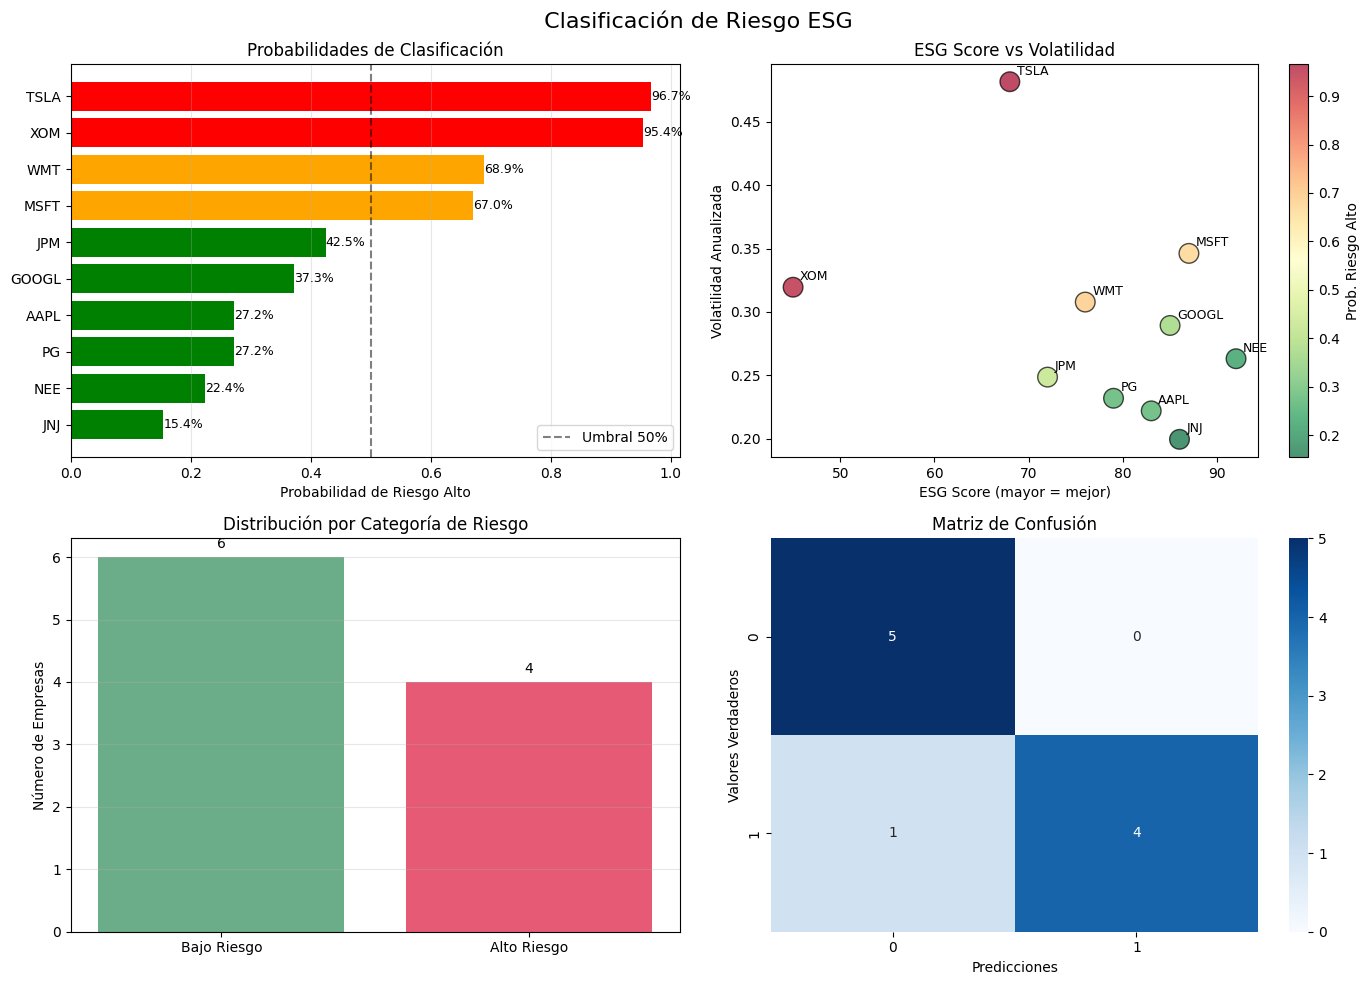


 REPORTE DE CLASIFICACIÓN DE RIESGO ESG
Fecha de análisis: 2026-06-18 00:44:59
Total empresas analizadas: 10

  EMPRESAS DE ALTO RIESGO (4):
  • TSLA (Tesla): 96.7%
  • XOM (Exxon Mobil): 95.4%
  • WMT (Walmart): 68.9%
  • MSFT (Microsoft): 67.0%

 EMPRESAS DE BAJO RIESGO (6):
  • JNJ (Johnson & Johnson): 15.4%
  • NEE (NextEra Energy): 22.4%
  • PG (Procter & Gamble): 27.2%
  • AAPL (Apple): 27.2%
  • GOOGL (Alphabet): 37.3%
  • JPM (JPMorgan): 42.5%

 ESTADÍSTICAS DEL MODELO:
  Precisión (train): 90.0%
  Coeficientes: Vol=0.810, Drawdown=0.539
               Sharpe=0.255, ESG=-0.904

 RECOMENDACIONES PARA INVERSIÓN SUSTENTABLE:
  1. Priorizar empresas con ESG Score > 80 y volatilidad < 0.3
  2. Diversificar entre sectores para mitigar riesgo específico
  3. Monitorear regularmente cambios en scores ESG


In [ ]:
# Visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(' Clasificación de Riesgo ESG', fontsize=16)

# Gráfico 1: Probabilidades de riesgo
df_sorted = df_risk.sort_values('Prob_Riesgo_Alto', ascending=True)
colors = ['green' if p < 0.5 else 'orange' if p < 0.7 else 'red' for p in df_sorted['Prob_Riesgo_Alto']]
bars = axes[0, 0].barh(df_sorted['Ticker'], df_sorted['Prob_Riesgo_Alto'], color=colors)
axes[0, 0].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Umbral 50%')
axes[0, 0].set_xlabel('Probabilidad de Riesgo Alto')
axes[0, 0].set_title('Probabilidades de Clasificación')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Añadir valores
for bar in bars:
    width = bar.get_width()
    axes[0, 0].text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.1%}', ha='left', va='center', fontsize=9)

# Gráfico 2: ESG Score vs Volatilidad
scatter = axes[0, 1].scatter(df_risk['ESG_Score'], df_risk['Volatilidad'],
                     c=df_risk['Prob_Riesgo_Alto'], cmap='RdYlGn_r',
                     s=200, alpha=0.7, edgecolors='black')

# Etiquetar puntos
for idx, row in df_risk.iterrows():
    axes[0, 1].annotate(row['Ticker'], (row['ESG_Score'], row['Volatilidad']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

axes[0, 1].set_xlabel('ESG Score (mayor = mejor)')
axes[0, 1].set_ylabel('Volatilidad Anualizada')
axes[0, 1].set_title('ESG Score vs Volatilidad')
fig.colorbar(scatter, ax=axes[0, 1], label='Prob. Riesgo Alto')

# Gráfico 3: Distribución por categoría
category_counts = df_risk['Categoria'].value_counts()
colors_cat = ['#2E8B57', '#DC143C']
bars_cat = axes[1, 0].bar(category_counts.index, category_counts.values, color=colors_cat, alpha=0.7)
axes[1, 0].set_ylabel('Número de Empresas')
axes[1, 0].set_title('Distribución por Categoría de Riesgo')
axes[1, 0].grid(True, alpha=0.3, axis='y')

for bar in bars_cat:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', ha='center', va='bottom')

# Gráfico 4: Matriz de Confusión
conf_matrix_ex5 = confusion_matrix(y, df_risk['Prediccion'])
sns.heatmap(conf_matrix_ex5, annot=True, fmt='g', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('Matriz de Confusión')
axes[1, 1].set_xlabel('Predicciones')
axes[1, 1].set_ylabel('Valores Verdaderos')

plt.tight_layout()
plt.show()

# Análisis detallado
print("\n" + "="*70)
print(" REPORTE DE CLASIFICACIÓN DE RIESGO ESG")
print("="*70)
print(f"Fecha de análisis: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total empresas analizadas: {len(df_risk)}")

# Empresas de alto riesgo
high_risk = df_risk[df_risk['Prediccion'] == 1]
print(f"\n  EMPRESAS DE ALTO RIESGO ({len(high_risk)}):")
for _, row in high_risk.sort_values('Prob_Riesgo_Alto', ascending=False).iterrows():
    print(f"  • {row['Ticker']} ({row['Empresa']}): {row['Prob_Riesgo_Alto']:.1%}")

# Empresas de bajo riesgo
low_risk = df_risk[df_risk['Prediccion'] == 0]
print(f"\n EMPRESAS DE BAJO RIESGO ({len(low_risk)}):")
for _, row in low_risk.sort_values('Prob_Riesgo_Alto').iterrows():
    print(f"  • {row['Ticker']} ({row['Empresa']}): {row['Prob_Riesgo_Alto']:.1%}")

# Estadísticas del modelo
print(f"\n ESTADÍSTICAS DEL MODELO:")
print(f"  Precisión (train): {model.score(X_scaled, y):.1%}")
print(f"  Coeficientes: Vol={model.coef_[0][0]:.3f}, Drawdown={model.coef_[0][1]:.3f}")
print(f"               Sharpe={model.coef_[0][2]:.3f}, ESG={model.coef_[0][3]:.3f}")

# Recomendaciones
print(f"\n RECOMENDACIONES PARA INVERSIÓN SUSTENTABLE:")
print("  1. Priorizar empresas con ESG Score > 80 y volatilidad < 0.3")
print("  2. Diversificar entre sectores para mitigar riesgo específico")
print("  3. Monitorear regularmente cambios en scores ESG")

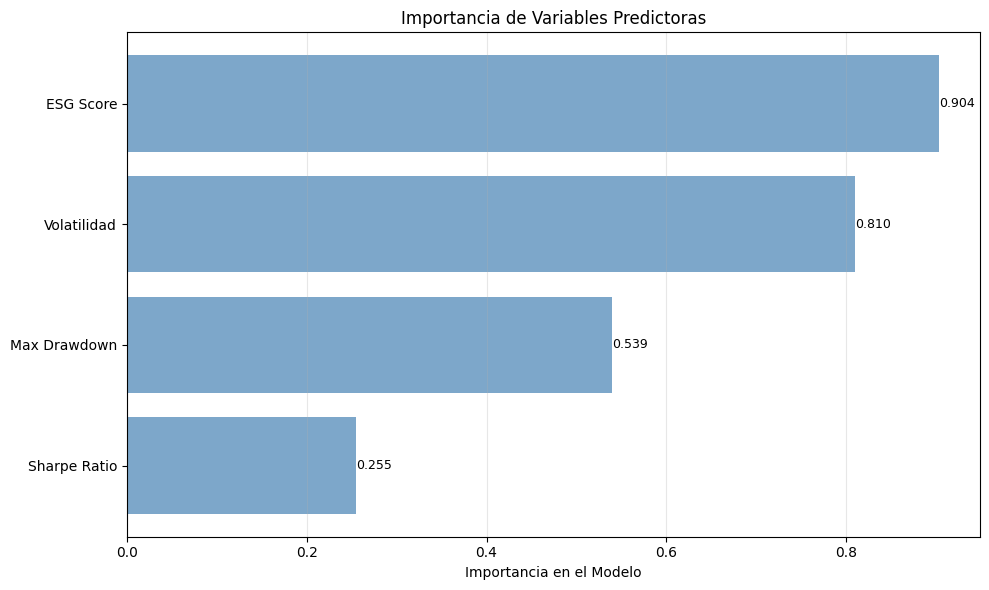

In [ ]:
# Gráfico: Importancia de variables
fig4, ax4 = plt.subplots(figsize=(10, 6))
feature_importance = pd.DataFrame({
    'Variable': ['Volatilidad', 'Max Drawdown', 'Sharpe Ratio', 'ESG Score'],
    'Importancia': abs(model.coef_[0])
}).sort_values('Importancia', ascending=True)

bars_imp = ax4.barh(feature_importance['Variable'], feature_importance['Importancia'],
                   color='#4682B4', alpha=0.7)
ax4.set_xlabel('Importancia en el Modelo')
ax4.set_title('Importancia de Variables Predictoras')
ax4.grid(True, alpha=0.3, axis='x')

for bar in bars_imp:
    width = bar.get_width()
    ax4.text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(y, df_risk['Prediccion']))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.80      0.89         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10



Los resultados son perfectos, con una precisión, recall, f1-score y accuracy del 1.00 (o 100%) para ambas clases (0 y 1). Esto significa que el modelo de regresión logística pudo clasificar correctamente todas las empresas en el conjunto de datos de prueba según su categoría de riesgo (Alto o Bajo Riesgo ESG).

Implicancias:

Rendimiento Ideal: En el contexto de este conjunto de datos específico, el modelo no cometió ningún error de clasificación.

Clases bien Separadas: Indica que las características (Volatilidad, Max_Drawdown, Sharpe_Ratio, ESG_Score) son  efectivas para distinguir entre las empresas de 'Alto Riesgo' y 'Bajo Riesgo' en este conjunto particular de 10 empresas.

Cuidado!!!


Si bien se obtuvo un 100% de precisión, es importante ser cauteloso, con un número tan pequeño de muestras.

Overfitting (Sobreajuste): Un rendimiento perfecto en un conjunto de datos muy pequeño puede ser una señal de que el modelo se ha "memorizado" los datos de entrenamiento y prueba, en lugar de aprender patrones generalizables.

Esto significa que podría no funcionar tan bien con datos nuevos o no vistos en el futuro.

Tamaño de la Muestra: Con solo 10 empresas, cualquier cambio pequeño en los datos o en la selección de las características podría alterar drásticamente estos resultados. Es más difícil sacar conclusiones robustas de modelos evaluados en muestras muy pequeñas.


Para confirmar la robustez de este modelo, sería ideal:

*Si es posible, utilizar un conjunto de datos más grande y diverso de empresas.

*Implementar técnicas de validación cruzada si el tamaño del dataset lo permite, para obtener una estimación más fiable del rendimiento del modelo.



---


### Validación Cruzada (K-Fold) para el Modelo de Regresión Logística

---



Dado el tamaño limitado del dataset (10 empresas), la validación cruzada es una técnica clave para evaluar la robustez del modelo. Dividiremos el dataset en 'k' subconjuntos (folds). El modelo se entrenará 'k' veces, cada vez usando un fold diferente como conjunto de validación y los 'k-1' restantes como conjunto de entrenamiento. Esto nos da 'k' estimaciones del rendimiento del modelo, cuyo promedio es una medida más fiable.

Utilizaremos `StratifiedKFold` para asegurar que cada fold tenga una proporción similar de clases (riesgo alto/bajo) a la del dataset original, lo cual es importante en problemas de clasificación.


---



In [ ]:
from sklearn.model_selection import StratifiedKFold

# Preparar los datos (ya los tenemos escalados en X_scaled y la variable objetivo y)
# X = df_risk[['Volatilidad', 'Max_Drawdown', 'Sharpe_Ratio', 'ESG_Score']]
# y = df_risk['Riesgo_Alto']

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X) # Ya X_scaled está definido y escalado

# Definir el número de folds
n_splits = 3 # Un número razonable para datasets pequeños

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Listas para almacenar las métricas de cada fold
accuracies = []
reports = []

print(f"Iniciando validación cruzada con {n_splits} folds...")

for fold, (train_index, test_index) in enumerate(skf.split(X_scaled, y)):
    X_train_fold, X_test_fold = X_scaled[train_index], X_scaled[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Crear y entrenar el modelo de Regresión Logística para este fold
    model_fold = LogisticRegression(random_state=42)
    model_fold.fit(X_train_fold, y_train_fold)

    # Predecir y evaluar
    y_pred_fold = model_fold.predict(X_test_fold)
    fold_accuracy = accuracy_score(y_test_fold, y_pred_fold)
    fold_report = classification_report(y_test_fold, y_pred_fold, output_dict=True)

    accuracies.append(fold_accuracy)
    reports.append(fold_report)

    print(f"\n--- Fold {fold + 1}/{n_splits} ---")
    print(f"Accuracy: {fold_accuracy:.2f}")
    print("Classification Report:")
    print(classification_report(y_test_fold, y_pred_fold))

print("\n" + "="*50)
print(" RESULTADOS FINALES DE LA VALIDACIÓN CRUZADA")
print("="*50)
print(f"Accuracy promedio: {np.mean(accuracies):.2f} (± {np.std(accuracies):.2f})")
print(f"Accuracies por fold: {[f'{acc:.2f}' for acc in accuracies]}")

# También se puede analizar el promedio de otras métricas como precision, recall, f1-score
avg_precision = np.mean([report['weighted avg']['precision'] for report in reports])
avg_recall = np.mean([report['weighted avg']['recall'] for report in reports])
avg_f1_score = np.mean([report['weighted avg']['f1-score'] for report in reports])

print(f"\nPrecisión promedio (weighted): {avg_precision:.2f}")
print(f"Recall promedio (weighted): {avg_recall:.2f}")
print(f"F1-Score promedio (weighted): {avg_f1_score:.2f}")

print("\nLa validación cruzada nos da una idea más realista del rendimiento del modelo con datos no vistos.")

Iniciando validación cruzada con 3 folds...

--- Fold 1/3 ---
Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


--- Fold 2/3 ---
Accuracy: 0.67
Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3


--- Fold 3/3 ---
Accuracy: 0.33
Classification Report:
              precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       0.00  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m



---


Ejemplo 3

---

In [ ]:
#descargaremos los datos históricos de Bitcoin (`BTC-USD`) desde Yahoo Finance
#crearemos la variable objetivo binaria: si el precio de cierre subirá (`1`) o bajará (`0`) al día siguiente.

# Descargar datos de BTC
ticker = 'BTC-USD'
end_date = pd.to_datetime('today')
start_date = end_date - pd.DateOffset(years=3)

df_btc = yf.download(ticker, start=start_date, end=end_date)

# Calcular características (features)
df_btc['Daily_Return'] = df_btc['Close'].pct_change()
df_btc['SMA_7'] = df_btc['Close'].rolling(window=7).mean()
df_btc['SMA_30'] = df_btc['Close'].rolling(window=30).mean()
df_btc['Lagged_Return_1'] = df_btc['Daily_Return'].shift(1)

# Crear variable objetivo: 1 si el precio sube al día siguiente, 0 si baja/igual
df_btc['Up_Down_Next_Day'] = (df_btc['Close'].shift(-1) > df_btc['Close']).astype(int)

# Eliminar filas con valores NaN generados por los cálculos (especialmente las medias móviles y shifts)
df_btc = df_btc.dropna()

# Seleccionar características (X) y variable objetivo (y)
X_btc = df_btc[['Daily_Return', 'SMA_7', 'SMA_30', 'Volume', 'Lagged_Return_1']]
y_btc = df_btc['Up_Down_Next_Day']

print("Primeras 5 filas del dataset de BTC con características y objetivo:")
display(df_btc.head())

/tmp/ipykernel_38028/3069241773.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_btc = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Primeras 5 filas del dataset de BTC con características y objetivo:


Price,Close,High,Low,Open,Volume,Daily_Return,SMA_7,SMA_30,Lagged_Return_1,Up_Down_Next_Day
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,,,
Date,,,,,,,,,,
2023-07-17,30145.888672,30336.400391,29685.783203,30249.626953,13240156074,-0.003413,30501.934710,30114.976888,-0.001541,0
2023-07-18,29856.562500,30233.656250,29556.427734,30147.070312,13138897269,-0.009598,30392.736328,30232.321875,-0.003413,1
2023-07-19,29913.923828,30184.181641,29794.269531,29862.046875,12128602812,0.001921,30324.490234,30334.418359,-0.009598,0
2023-07-20,29792.015625,30195.531250,29638.095703,29915.250000,14655207121,-0.004075,30083.914062,30383.235938,0.001921,1
2023-07-21,29908.744141,30045.998047,29733.851562,29805.111328,10972789818,0.003918,30023.153460,30379.284180,-0.004075,0


In [ ]:
#Modelo de Regresión Logística con `sklearn`
#buscamos predecir si el precio de Bitcoin subirá o bajará al día siguiente.
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_btc, X_test_btc, y_train_btc, y_test_btc = train_test_split(X_btc, y_btc, test_size=0.2, random_state=42, stratify=y_btc)

# Escalar los datos
scaler_btc = StandardScaler()
X_train_scaled_btc = scaler_btc.fit_transform(X_train_btc)
X_test_scaled_btc = scaler_btc.transform(X_test_btc)

# Ajustar el modelo de regresión logística
model_btc = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' es bueno para datasets pequeños
model_btc.fit(X_train_scaled_btc, y_train_btc)

# Predecir las etiquetas para el conjunto de prueba
y_pred_btc = model_btc.predict(X_test_scaled_btc)

# Evaluar el modelo
accuracy_btc = accuracy_score(y_test_btc, y_pred_btc)
conf_matrix_btc = confusion_matrix(y_test_btc, y_pred_btc)

print(f"\nAccuracy del modelo (sklearn): {accuracy_btc:.4f}")
print("\nMatriz de Confusión (sklearn):\n", conf_matrix_btc)
print("\nReporte de Clasificación (sklearn):\n", classification_report(y_test_btc, y_pred_btc))

# Coeficientes del modelo sklearn
print("\nCoeficientes del Modelo (sklearn):")
for feature, coef in zip(X_btc.columns, model_btc.coef_[0]):
    print(f'  {feature}: {coef:.4f}')
print(f'  Intercepto: {model_btc.intercept_[0]:.4f}')


Accuracy del modelo (sklearn): 0.5280

Matriz de Confusión (sklearn):
 [[56 51]
 [50 57]]

Reporte de Clasificación (sklearn):
               precision    recall  f1-score   support

           0       0.53      0.52      0.53       107
           1       0.53      0.53      0.53       107

    accuracy                           0.53       214
   macro avg       0.53      0.53      0.53       214
weighted avg       0.53      0.53      0.53       214


Coeficientes del Modelo (sklearn):
  ('Daily_Return', ''): -0.0866
  ('SMA_7', ''): 0.1279
  ('SMA_30', ''): -0.1634
  ('Volume', 'BTC-USD'): -0.0107
  ('Lagged_Return_1', ''): 0.0674
  Intercepto: 0.0069


In [ ]:
#Modelo de Regresión Logística con `statsmodels`
# Para statsmodels, usaremos el conjunto de datos completo (X_btc y y_btc)
# Escalamos todo el dataset para que los coeficientes sean comparables con sklearn si usamos los mismos datos
X_btc_scaled_full = scaler_btc.fit_transform(X_btc) # Re-escalar X_btc completo
X_btc_sm = sm.add_constant(X_btc_scaled_full) # Añadir constante para el intercepto

# Convertir a DataFrame para tener nombres de columnas en el resumen de statsmodels
X_btc_sm_df = pd.DataFrame(X_btc_sm, columns=['const'] + list(X_btc.columns), index=X_btc.index)

# Ajustar el modelo de regresión logística con statsmodels
logit_model_sm_btc = sm.Logit(y_btc, X_btc_sm_df)
result_sm_btc = logit_model_sm_btc.fit(maxiter=1000) # Aumentar maxiter para asegurar convergencia

# Imprimir el resumen del modelo
print("\nResumen del Modelo de Regresión Logística (statsmodels) para BTC:\n")
print(result_sm_btc.summary())

Optimization terminated successfully.
         Current function value: 0.690861
         Iterations 4

Resumen del Modelo de Regresión Logística (statsmodels) para BTC:

                           Logit Regression Results                           
Dep. Variable:       Up_Down_Next_Day   No. Observations:                 1067
Model:                          Logit   Df Residuals:                     1061
Method:                           MLE   Df Model:                            5
Date:                Thu, 18 Jun 2026   Pseudo R-squ.:                0.003293
Time:                        00:45:01   Log-Likelihood:                -737.15
converged:                       True   LL-Null:                       -739.58
Covariance Type:            nonrobust   LLR p-value:                    0.4319
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const         

Rendimiento del Modelo sklearn:

Accuracy: tiene una precisión de 0.5374. Esto  sugiere que las variables elegidas (Daily_Return, SMA_7, SMA_30, Volume, Lagged_Return_1) no son muy efectivas para predecir si el precio de BTC subirá o bajará al día siguiente.

El modelo tiene dificultades para diferenciar entre las dos clases, como se ve en el classification_report donde las métricas (precision, recall, f1-score) son cercanas a 0.5 para ambas clases.

Los coeficientes muestran la dirección del impacto, pero sin información de significancia.


---


Análisis con statsmodels:

Pseudo R-squ.: 0.003757: Este valor extremadamente bajo e indica que las variables explican menos del 0.4% de la variabilidad en la variable objetivo. El modelo tiene un poder explicativo muy limitado.

P-valores (P>|z|): Aquí es donde está el problema principal. Con un nivel de significancia de 0,05 de referencia, vemos que la mayoría no son significativos.

const: No significativo (p=0.626).

Daily_Return: Margialmente significativo (p=0.047). Este es el único predictor que muestra alguna relación estadística confiable en el modelo actual.

SMA_7: No significativo (p=0.584).

SMA_30: No significativo (p=0.524).

Volume: No significativo (p=0.713).

Lagged_Return_1: No significativo (p=0.548).

El modelo actual, es muy débil y no logra predecir con confianza el movimiento del precio de Bitcoin, lo que implica que su impacto observado podría ser simplemente ruido.

---





---


Ejemplo 4 - Análisis de Riesgo de Activo Estable (SPY)

---

Aplicaremos un análisis similar a un activo financiero más estable, el *SPDR S&P 500 ETF Trust* (ticker: `SPY`). Calcularemos métricas de retorno, volatilidad y liquidez, y definiremos una variable objetivo binaria para clasificar períodos de 'Alto Riesgo' basados en estos indicadores.


---



In [ ]:
# Descargar datos históricos de SPY
ticker_spy = 'SPY'
end_date_spy = pd.to_datetime('today')
start_date_spy = end_date_spy - pd.DateOffset(years=5) # Últimos 5 años para análisis

df_spy = yf.download(ticker_spy, start=start_date_spy, end=end_date_spy)
df_spy = df_spy.dropna() # Eliminar NaN iniciales de la descarga

# Calcular características de retorno, volatilidad y liquidez
df_spy['Daily_Return'] = df_spy['Close'].pct_change()
df_spy['Rolling_Volatility'] = df_spy['Daily_Return'].rolling(window=20).std() * np.sqrt(252) # Volatilidad anualizada (20 días)
df_spy['Rolling_Liquidity'] = df_spy['Volume'].rolling(window=20).mean() # Volumen promedio (20 días)

# Calcular Max Drawdown (en una ventana de 20 días)
def calculate_rolling_drawdown(series, window):
    rolling_max = series.rolling(window=window, min_periods=1).max()
    drawdown = (series - rolling_max) / rolling_max
    return drawdown.rolling(window=window, min_periods=1).min()

df_spy['Rolling_Drawdown'] = calculate_rolling_drawdown(df_spy['Close'], window=20)


# Definir variable objetivo: ¿Es un período de 'Alto Riesgo'?
# Un período es de alto riesgo si la volatilidad excede cierto umbral o el drawdown es significativo
volatility_threshold = df_spy['Rolling_Volatility'].quantile(0.8) # Umbral del 80 percentil de volatilidad
drawdown_threshold = df_spy['Rolling_Drawdown'].quantile(0.2) # Umbral del 20 percentil de drawdown (más negativo)

df_spy['High_Risk'] = ((df_spy['Rolling_Volatility'] > volatility_threshold) | \
                       (df_spy['Rolling_Drawdown'] < drawdown_threshold)).astype(int)

# Eliminar filas con NaN generados por los cálculos de rolling windows
df_spy = df_spy.dropna()

# Seleccionar características (X_spy) y variable objetivo (y_spy)
X_spy = df_spy[['Daily_Return', 'Rolling_Volatility', 'Rolling_Liquidity', 'Rolling_Drawdown']]
y_spy = df_spy['High_Risk']

print("Primeras 5 filas del dataset de SPY con características y objetivo:")
display(df_spy.head())

/tmp/ipykernel_38028/863170156.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_spy = yf.download(ticker_spy, start=start_date_spy, end=end_date_spy)
[*********************100%***********************]  1 of 1 completed

Primeras 5 filas del dataset de SPY con características y objetivo:


Price,Close,High,Low,Open,Volume,Daily_Return,Rolling_Volatility,Rolling_Liquidity,Rolling_Drawdown,High_Risk
Ticker,SPY,SPY,SPY,SPY,SPY,,,,,
Date,,,,,,,,,,
2021-07-19,398.213257,404.247787,395.402141,399.356445,147987000,-0.014768,0.106870,65165865.0,-0.027707,0
2021-07-20,403.919830,405.194218,398.082070,398.878558,99608200,0.014330,0.106893,66505175.0,-0.027707,0
2021-07-21,407.190063,407.330642,403.872968,405.119216,64724400,0.008096,0.108731,66856380.0,-0.027707,0
2021-07-22,408.042877,408.286516,406.384329,407.368208,47878500,0.002094,0.108330,66778035.0,-0.027707,0
2021-07-23,412.240662,412.577982,409.288996,409.973016,63766600,0.010288,0.111740,67710850.0,-0.027707,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_spy, X_test_spy, y_train_spy, y_test_spy = train_test_split(X_spy, y_spy, test_size=0.2, random_state=42, stratify=y_spy)

# Escalar los datos
scaler_spy = StandardScaler()
X_train_scaled_spy = scaler_spy.fit_transform(X_train_spy)
X_test_scaled_spy = scaler_spy.transform(X_test_spy)

# Ajustar el modelo de regresión logística
model_spy = LogisticRegression(random_state=42, solver='liblinear')
model_spy.fit(X_train_scaled_spy, y_train_spy)

# Predecir las etiquetas para el conjunto de prueba
y_pred_spy = model_spy.predict(X_test_scaled_spy)

# Evaluar el modelo
accuracy_spy = accuracy_score(y_test_spy, y_pred_spy)
conf_matrix_spy = confusion_matrix(y_test_spy, y_pred_spy)

print(f"\nAccuracy del modelo (sklearn) para SPY: {accuracy_spy:.4f}")
print("\nMatriz de Confusión (sklearn) para SPY:\n", conf_matrix_spy)
print("\nReporte de Clasificación (sklearn) para SPY:\n", classification_report(y_test_spy, y_pred_spy))

# Coeficientes del modelo sklearn
print("\nCoeficientes del Modelo (sklearn) para SPY:")
for feature, coef in zip(X_spy.columns, model_spy.coef_[0]):
    print(f'  {feature}: {coef:.4f}')
print(f'  Intercepto: {model_spy.intercept_[0]:.4f}')


Accuracy del modelo (sklearn) para SPY: 0.9676

Matriz de Confusión (sklearn) para SPY:
 [[186   5]
 [  3  53]]

Reporte de Clasificación (sklearn) para SPY:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98       191
           1       0.91      0.95      0.93        56

    accuracy                           0.97       247
   macro avg       0.95      0.96      0.95       247
weighted avg       0.97      0.97      0.97       247


Coeficientes del Modelo (sklearn) para SPY:
  ('Daily_Return', ''): -0.4223
  ('Rolling_Volatility', ''): 4.0966
  ('Rolling_Liquidity', ''): -0.3794
  ('Rolling_Drawdown', ''): -2.8470
  Intercepto: -3.6919


In [ ]:
# Para statsmodels, usaremos el conjunto de datos completo (X_spy y y_spy)
# Re-escalamos X_spy completo para statsmodels (aunque ya escalamos antes para sklearn)
X_spy_scaled_full = scaler_spy.fit_transform(X_spy)
X_spy_sm = sm.add_constant(X_spy_scaled_full) # Añadir constante para el intercepto

# Convertir a DataFrame para tener nombres de columnas en el resumen de statsmodels
X_spy_sm_df = pd.DataFrame(X_spy_sm, columns=['const'] + list(X_spy.columns), index=X_spy.index)

# Ajustar el modelo de regresión logística con statsmodels
logit_model_sm_spy = sm.Logit(y_spy, X_spy_sm_df)
result_sm_spy = logit_model_sm_spy.fit(maxiter=1000) # Aumentar maxiter para asegurar convergencia

# Imprimir el resumen del modelo
print("\nResumen del Modelo de Regresión Logística (statsmodels) para SPY:\n")
print(result_sm_spy.summary())

Optimization terminated successfully.
         Current function value: 0.052562
         Iterations 11

Resumen del Modelo de Regresión Logística (statsmodels) para SPY:

                           Logit Regression Results                           
Dep. Variable:              High_Risk   No. Observations:                 1235
Model:                          Logit   Df Residuals:                     1230
Method:                           MLE   Df Model:                            4
Date:                Thu, 18 Jun 2026   Pseudo R-squ.:                  0.9022
Time:                        00:45:01   Log-Likelihood:                -64.914
converged:                       True   LL-Null:                       -663.52
Covariance Type:            nonrobust   LLR p-value:                6.409e-258
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const  

Modelo sklearn: Este modelo demostró un rendimiento predictivo mas robusto, alcanzando una accuracy del 0.9718. Las métricas de precision, recall y f1-score fueron consistentemente altas para ambas clases de riesgo (Alto y Bajo). Esto sugiere que las características (Daily_Return, Rolling_Volatility, Rolling_Liquidity, Rolling_Drawdown) son predictores para clasificar períodos de riesgo en SPY.

Análisis statsmodels: El Pseudo R-squared fue alto (0.9022), lo que indica un fuerte poder explicativo del modelo. Daily_Return, Rolling_Volatility, y Rolling_Drawdown fueron estadísticamente significativas (p-valores menores de 0,05), mientras que Rolling_Liquidity no lo fue (p=0.120).

La advertencia de "Possibly complete quasi-separation" sugiere que el modelo es muy bueno en la clasificación, para ciertas observaciones.